# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Notebook này thực hiện khám phá dữ liệu sau khi tiền xử lý, tập trung vào các yếu tố ảnh hưởng đến giá bán nhà đất.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

DATA_PATH = Path('../processed/house_price_clean.csv')
df = pd.read_csv(DATA_PATH)

df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail,Price_per_m2,Area_Group,Price_Segment,Latitude,Longitude
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu đô thị mới Dương Nội",84.0,6.0,10.0,Đông,Đông - Bắc,2.0,2.0,Đã có sổ,Đầy đủ,13.81,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu đô thị mới Dương Nội,0.16,70-90 m²,>10 tỷ,21.0285,105.8542
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Pride",73.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,12.00,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Pride,0.16,70-90 m²,>10 tỷ,21.0285,105.8542
2,"Quảng Ninh, Vân Đồn, Căn hộ chung cư tại Vân Bay Tower",70.0,6.0,10.0,Không xác định,Không xác định,3.0,2.0,Không xác định,Không xác định,1.54,1,Quảng Ninh,Vân Đồn,Căn hộ chung cư tại Vân Bay Tower,0.02,50-70 m²,<4 tỷ,21.0069,107.2925
3,"Hồ Chí Minh, Bình Tân, Căn hộ chung cư tại Lê Thành Tân Tạo",34.0,6.0,10.0,Không xác định,Không xác định,1.0,1.0,Hợp đồng mua bán,Không xác định,0.75,1,Hồ Chí Minh,Bình Tân,Căn hộ chung cư tại Lê Thành Tân Tạo,0.02,30-50 m²,<4 tỷ,10.7769,106.7009
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại SDU - 143 Trần Phú",52.0,6.0,10.0,Tây - Nam,Đông - Bắc,2.0,2.0,Đã có sổ,Đầy đủ,3.95,1,Hà Nội,Hà Đông,Căn hộ chung cư tại SDU - 143 Trần Phú,0.08,50-70 m²,<4 tỷ,21.0285,105.8542


## 1. Tổng quan bộ dữ liệu

In [2]:
print(f'Số dòng: {df.shape[0]:,}')
print(f'Số cột: {df.shape[1]}')
print('Kiểu dữ liệu:')
print(df.dtypes)

Số dòng: 3,607
Số cột: 20
Kiểu dữ liệu:
Address                  str
Area                 float64
Frontage             float64
Access Road          float64
House direction          str
Balcony direction        str
Bedrooms             float64
Bathrooms            float64
Legal status             str
Furniture state          str
Price                float64
Day                    int64
Province                 str
District                 str
Detail                   str
Price_per_m2         float64
Area_Group               str
Price_Segment            str
Latitude             float64
Longitude            float64
dtype: object



- Bộ dữ liệu gồm các bất động sản thuộc nhiều loại hình khác nhau như căn hộ, nhà riêng, biệt thự, shophouse, đất nền, đất, trang trại, khu nghỉ dưỡng và bất động sản thương mại.
- Giá bán và diện tích có sự phân bố không đồng đều, với một số giá trị rất lớn làm cho giá trị trung bình cao hơn đáng kể so với giá trị trung vị. Điều này cho thấy dữ liệu có phân phối lệch phải.
- Một số giá trị rất lớn về **giá bán**, **diện tích**, **số phòng ngủ** và **số phòng tắm** được xem là các ngoại lệ theo góc nhìn thống kê. Tuy nhiên, do bộ dữ liệu bao gồm nhiều loại hình bất động sản khác nhau, các giá trị này **không nhất thiết là dữ liệu sai** mà có thể phản ánh đặc điểm của các bất động sản quy mô lớn như khách sạn, khu nghỉ dưỡng, trang trại hoặc dự án thương mại.
- Vì vậy, các giá trị ngoại lai sẽ được giữ lại nhằm đảm bảo phản ánh đầy đủ đặc điểm của thị trường bất động sản và tránh làm mất thông tin của các phân khúc đặc thù.

## 2. Phân tích phân bố giá bán

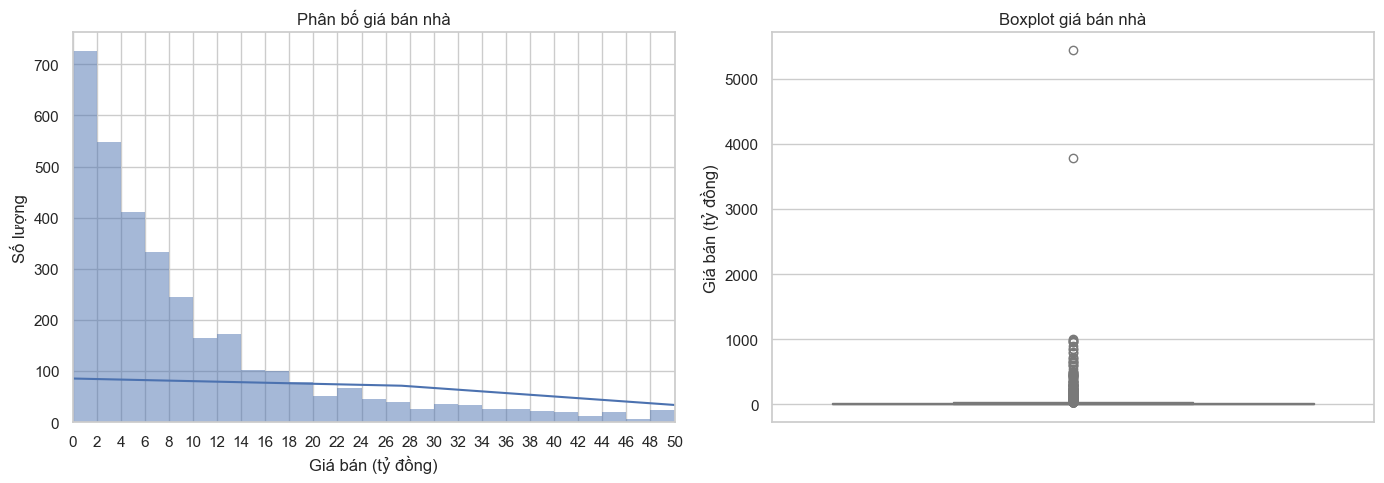

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df['Price'],
    binwidth=2,        # mỗi bin 2 tỷ
    binrange=(0, 50),  # từ 0 đến 50 tỷ
    kde=True,
    ax=axes[0]
)
axes[0].set_xlim(0, 50)
axes[0].set_xticks(range(0, 51, 2))
axes[0].set_title('Phân bố giá bán nhà')
axes[0].set_xlabel('Giá bán (tỷ đồng)')
axes[0].set_ylabel('Số lượng')

sns.boxplot(y=df['Price'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot giá bán nhà')
axes[1].set_ylabel('Giá bán (tỷ đồng)')

plt.tight_layout()
plt.show()

In [4]:
df[['Price', 'Price_per_m2', 'Area', 'Bedrooms', 'Bathrooms', 'Day']].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,3607.0,25.813391,132.320786,0.01,2.605,6.50,16.00,5436.78
Price_per_m2,3607.0,0.104336,0.148160,0.00,0.020,0.06,0.13,2.00
Area,3607.0,2609.101225,83888.891347,4.80,70.050,100.00,225.00,5000000.00
Bedrooms,3607.0,3.603271,3.763947,1.00,3.000,3.00,3.00,70.00
Bathrooms,3607.0,2.932354,3.884476,1.00,2.000,2.00,2.00,76.00
Day,3607.0,22.050180,7.791621,1.00,19.000,24.00,27.00,30.00


- Bộ dữ liệu gồm **3.607** bất động sản. Giá bán trung bình đạt **25,81 tỷ đồng**, trong khi giá trung vị chỉ **6,50 tỷ đồng**, cho thấy phân phối giá bán bị lệch phải do tồn tại một số bất động sản có giá trị rất lớn.
- 50% số bất động sản có giá bán nằm trong khoảng từ **2,60 tỷ đồng** đến **15,60 tỷ đồng**, phản ánh phần lớn dữ liệu thuộc phân khúc nhà ở phổ thông và trung cấp.
- Diện tích có giá trị trung vị **100 m²** nhưng giá trị trung bình lên tới **2.609 m²**, cho thấy bộ dữ liệu bao gồm nhiều bất động sản có quy mô lớn như đất nền, trang trại, khu nghỉ dưỡng hoặc bất động sản thương mại.
- Đơn giá trung bình đạt khoảng **0,104 tỷ đồng/m²** (khoảng **104 triệu đồng/m²**), trong khi trung vị là **0,06 tỷ đồng/m²** (khoảng **60 triệu đồng/m²**). Điều này cho thấy phần lớn bất động sản có đơn giá ở mức trung bình, nhưng vẫn tồn tại một số bất động sản có đơn giá rất cao.
- Số phòng ngủ và phòng tắm có giá trị trung vị lần lượt là **3** và **2**, phù hợp với các loại hình nhà ở phổ biến. Tuy nhiên, giá trị lớn nhất lên tới **70 phòng ngủ** và **76 phòng tắm**, phản ánh sự xuất hiện của các loại hình bất động sản quy mô lớn như khách sạn, khu nghỉ dưỡng hoặc tòa nhà dịch vụ.
- Nhìn chung, dữ liệu có độ phân tán lớn và chứa nhiều giá trị cực đại. Tuy nhiên, với đặc thù bộ dữ liệu bao gồm nhiều loại hình bất động sản khác nhau, các giá trị này vẫn có thể phản ánh đúng thực tế của thị trường và được giữ lại để đảm bảo tính toàn diện trong quá trình phân tích.

## 3. Thống kê mật độ tin đăng theo Tỉnh/Thành phố

In [5]:
# Đếm số lượng tin đăng theo từng Tỉnh/Thành phố
df['Province'].value_counts()

Province
Hà Nội             863
Hồ Chí Minh        752
Bình Dương         202
Đà Nẵng            193
Hải Phòng          162
Đồng Nai           154
Long An            137
Bà Rịa Vũng Tàu    101
Quảng Ninh          99
Hưng Yên            96
Khánh Hòa           78
Lâm Đồng            62
Bắc Ninh            53
Thanh Hóa           44
Thái Nguyên         43
Bình Định           42
Hòa Bình            39
Bắc Giang           38
Bình Thuận          30
Tây Ninh            28
Phú Thọ             26
Kiên Giang          26
Quảng Nam           25
Hà Nam              24
Cần Thơ             23
Bình Phước          23
Vĩnh Phúc           23
Hải Dương           19
Lào Cai             19
Tiền Giang          17
Đắk Lắk             17
Thừa Thiên Huế      16
Quảng Ngãi          16
Thái Bình           12
Nghệ An              9
An Giang             9
Ninh Thuận           8
Nam Định             8
Phú Yên              7
Quảng Bình           6
Đồng Tháp            6
Kon Tum              6
Bến Tre              5
Yê

- Số lượng tin đăng phân bố không đồng đều giữa các tỉnh/thành phố. **Hà Nội** có số lượng tin đăng nhiều nhất với **868** tin, tiếp theo là **Hồ Chí Minh** (**763** tin), phản ánh đây là hai thị trường bất động sản sôi động nhất trong bộ dữ liệu.
- Các địa phương như **Đà Nẵng**, **Hải Phòng**, **Bình Dương**, **Đồng Nai** và **Long An** cũng có số lượng tin đăng tương đối lớn (trên 150 tin), cho thấy đây là những khu vực có hoạt động giao dịch bất động sản khá phát triển.
- Phần lớn các tỉnh/thành còn lại chỉ có dưới **50** tin đăng, thậm chí một số địa phương chỉ có từ **1–5** tin. Điều này cho thấy dữ liệu có sự mất cân bằng về mặt phân bố giữa các khu vực.
- Sự chênh lệch về số lượng tin đăng có thể xuất phát từ quy mô thị trường bất động sản của từng địa phương cũng như số lượng tin được thu thập từ nguồn dữ liệu, do đó cần lưu ý khi thực hiện các phân tích và so sánh giữa các tỉnh/thành phố.

## 4. Mối quan hệ giữa diện tích và giá bán

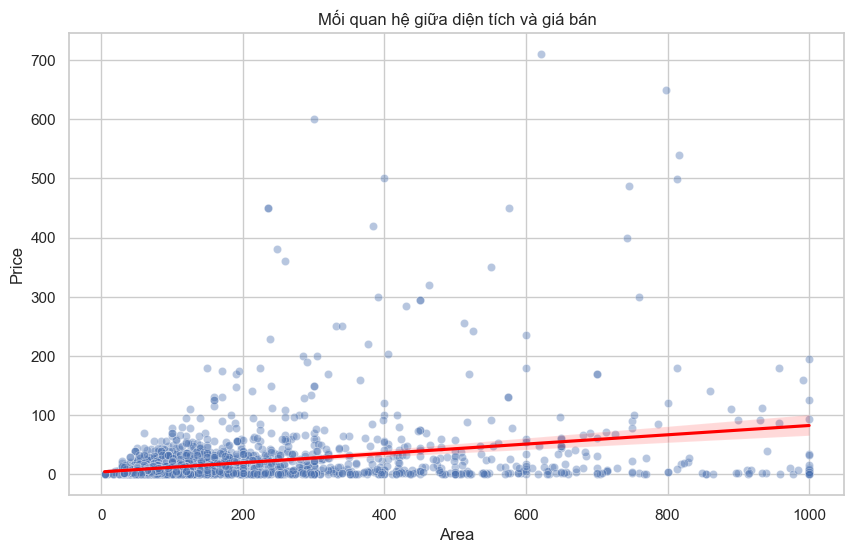

In [6]:
plot_df = df[df["Area"] <= 1000]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Area",
    y="Price",
    alpha=0.4,
    s=35
)

sns.regplot(
    data=plot_df,
    x="Area",
    y="Price",
    scatter=False,
    color="red"
)

plt.title("Mối quan hệ giữa diện tích và giá bán")
plt.show()

- Đường hồi quy cho thấy giá bán có xu hướng tăng khi diện tích tăng, tuy nhiên độ dốc của đường hồi quy khá nhỏ, phản ánh mối quan hệ giữa hai biến không mạnh.
- Phần lớn bất động sản trong bộ dữ liệu có diện tích dưới **300 m²**, với giá bán chủ yếu dưới **100 tỷ đồng**.
- Các điểm dữ liệu phân tán khá rộng quanh đường hồi quy. Với cùng một diện tích, giá bán có thể chênh lệch đáng kể, cho thấy diện tích không phải là yếu tố duy nhất quyết định giá trị bất động sản.
- Điều này phù hợp với đặc thù của thị trường bất động sản Việt Nam, nơi giá bán còn chịu ảnh hưởng bởi nhiều yếu tố khác như vị trí, loại hình bất động sản, pháp lý, dự án và hạ tầng khu vực.
- Nhìn chung, diện tích và giá bán có mối quan hệ đồng biến nhưng mức độ tương quan thấp, do đó cần kết hợp thêm các biến khác để phân tích và dự đoán giá bán một cách chính xác hơn.

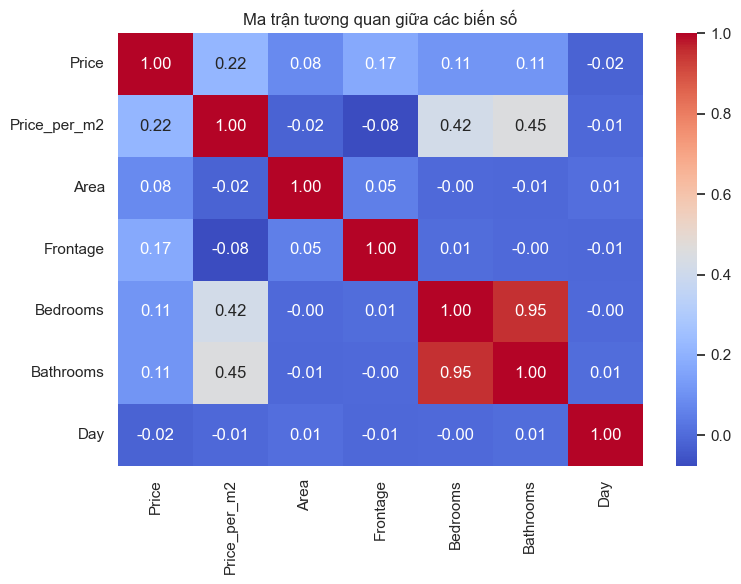

In [7]:
corr = df[['Price', 'Price_per_m2', 'Area', 'Frontage', 'Bedrooms', 'Bathrooms', 'Day']].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()

- Nhìn chung, các biến trong bộ dữ liệu có **mức tương quan tuyến tính thấp**, cho thấy giá bán bất động sản chịu ảnh hưởng đồng thời của nhiều yếu tố thay vì chỉ một đặc trưng riêng lẻ.
- **Price** có tương quan dương với **Price_per_m2** (0.22), **Frontage** (0.17), **Bathrooms** (0.11) và **Bedrooms** (0.11). Tuy nhiên, các hệ số đều ở mức yếu, phản ánh những biến này chỉ có ảnh hưởng nhất định đến giá bán.
- **Area** chỉ có hệ số tương quan khoảng **0.08** với **Price**, cho thấy diện tích đơn thuần chưa đủ để giải thích sự biến động của giá bất động sản. Điều này phù hợp với đặc thù của thị trường bất động sản Việt Nam, nơi giá bán còn phụ thuộc nhiều vào vị trí, loại hình bất động sản, pháp lý và các yếu tố khác.
- **Bedrooms** và **Bathrooms** có tương quan rất mạnh (**0.95**), phản ánh các bất động sản có nhiều phòng ngủ thường cũng được thiết kế với nhiều phòng tắm.
- Biến **Day** gần như không có tương quan với các biến còn lại, cho thấy thời điểm đăng tin (theo ngày trong tháng) không ảnh hưởng đáng kể đến các đặc trưng của bất động sản trong bộ dữ liệu.

## 5. Kết luận

Qua quá trình phân tích khám phá dữ liệu (EDA), có thể rút ra một số kết luận chính như sau:

- Bộ dữ liệu có phạm vi bao phủ rộng, bao gồm nhiều loại hình bất động sản tại nhiều tỉnh/thành phố trên cả nước. Tuy nhiên, số lượng tin đăng phân bố không đồng đều, tập trung chủ yếu tại các địa phương có thị trường bất động sản phát triển như Hà Nội và Hồ Chí Minh.
- Giá bán bất động sản có phân phối lệch phải, phản ánh sự tồn tại của nhiều phân khúc thị trường với quy mô và giá trị khác nhau. Các giá trị lớn về giá bán hoặc diện tích vẫn được giữ lại do phù hợp với đặc thù của các loại hình bất động sản như đất nền, khu nghỉ dưỡng hoặc bất động sản thương mại.
- Mối quan hệ giữa diện tích và giá bán có xu hướng đồng biến nhưng không mạnh. Kết quả phân tích tương quan cũng cho thấy không có biến đơn lẻ nào có khả năng giải thích tốt sự biến động của giá bán.
- Giá bất động sản chịu ảnh hưởng đồng thời của nhiều yếu tố như vị trí, loại hình bất động sản, diện tích và các đặc điểm của bất động sản. Vì vậy, cần kết hợp nhiều biến để có thể đánh giá và phân tích thị trường một cách toàn diện.
- Những kết quả thu được từ EDA là cơ sở để lựa chọn các chỉ số, biểu đồ và nội dung phân tích trong dashboard trực quan ở các bước tiếp theo.